A Complex Graph Design Example
=====

In [3]:
import os
import sys
print(sys.executable)
from pathlib import Path
from typing import TypedDict, Annotated, Sequence, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_core.documents import Document

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

/Users/mlstudio/Claude-Code/Agentic-AI/.venv/bin/python


/Users/mlstudio/Claude-Code/Agentic-AI/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/hf/0h4pd6zx1vv0dwjx8bgs9r_c0000gp/T/ipykernel_57961/1749327865.py:17: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [5]:
KNOWLEDGE = [
    "PyML Studio is a YouTube channel focused on explaining AI/ML/DL concepts.",
    (
        "Checkpointing in machine learning is the process of periodically saving a model’s state "
        "during training to a storage drive. It captures the architecture, weights (parameters), "
        "optimizer states, and training progress. This creates a snapshot so that training can resume exactly "
        "where it left off if the system crashes."
    ),
    (
        "A StateGraph is the core building block in LangGraph used to build stateful, "
        "multi-step AI agents and workflows. It defines a directed graph where nodes "
        "(functions or agents) communicate by reading and writing to a central, shared state object."
    ),
    (
        "Tool calling in an LLM is a capability that allows the AI to step outside its static "
        "training data and dynamically interact with external systems, databases, and APIs. "
        "Instead of merely generating text, the LLM determines it needs external information or an action, "
        "selects the appropriate tool, and provides structured instructions to execute it."
    ),
    (
        "Large Language Models (LLMs) learn tool-calling by training on paired datasets of user intents, "
        "tool definitions, and structured function calls. Through this process, they learn to translate a "
        "user's natural language request into a machine-readable format (like JSON or XML) that external systems "
        "can execute."
    ),
    (
        "Reinforcement Learning with Verifiable Rewards (RLVR) is an AI training paradigm that replaces "
        "subjective human feedback with objective, rule-based verification. "
        "Instead of relying on a human 'art critic,' the model is graded like a math teacher using an answer key, "
        "significantly improving AI reasoning and reliability."
    )
]

vector_store = InMemoryVectorStore(OpenAIEmbeddings(model="text-embedding-3-small"))
vector_store.add_documents([Document(page_content=text) for text in KNOWLEDGE])
vector_store.similarity_search("What is tool-calling?", k=2)

[Document(id='4db2ccbb-4f4c-437f-a349-4a5c58c1559c', metadata={}, page_content='Tool calling in an LLM is a capability that allows the AI to step outside its static training data and dynamically interact with external systems, databases, and APIs. Instead of merely generating text, the LLM determines it needs external information or an action, selects the appropriate tool, and provides structured instructions to execute it.'),
 Document(id='7caff38b-c636-4392-bb7e-aec269661dfa', metadata={}, page_content="Large Language Models (LLMs) learn tool-calling by training on paired datasets of user intents, tool definitions, and structured function calls. Through this process, they learn to translate a user's natural language request into a machine-readable format (like JSON or XML) that external systems can execute.")]

In [ ]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()

    for path in [current, *current.parents]:
        if (path / "pyproject.toml").exists():
            return path

    raise FileNotFoundError("Could not find project root containing pyproject.toml")

project_root = find_project_root(Path.cwd())
print(f"project_root: {project_root}")

load_dotenv(project_root / ".env")
assert os.getenv("GROQ_API_KEY"), "Please put the API key into '.env'"

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    reasoning_format="hidden"
)

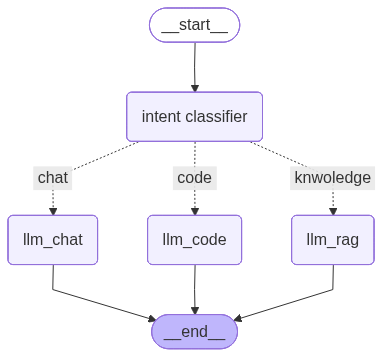

In [ ]:
class IntentClassifier(BaseModel):
    message_intent: Literal["chat", "knowledge", "code"] = Field(
        ...,
        description="Classifier whether the user wants to just chat, ask for knowledge, or code"
    )


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseModel], add_messages]
    message_intent: str | None


def classify_intent(state: AgentState) -> AgentState:
    structured_llm = llm.with_structured_output(IntentClassifier)
    system_prompt = SystemMessage("""
Determine / classify whether the user wants to chat ("chat"), retrieve knowledge ("knowledge"), or code ("code").
""")

    response = structured_llm.invoke(
        [system_prompt, state["messages"][-1]]
    )
    return {"message_intent": response.message_intent}


def llm_chat(state: AgentState) -> AgentState:
    system_prompt = SystemMessage("""You are a friendly and talkative chatbot.""")
    response = llm.invoke([system_prompt] + state["messages"])
    return {"messages": response}

def llm_rag(state: AgentState) -> AgentState:
    system_prompt = SystemMessage("""You are a helpful assistant to answer user's question from a knowledge base.""")
    response = llm.invoke([system_prompt] + state["messages"])
    return {"messages": response}

def llm_code(state: AgentState) -> AgentState:
    system_prompt = SystemMessage("""You are a helpful coding assistant with expertise in Python.""")
    response = llm.invoke([system_prompt] + state["messages"])
    return {"messages": response}

# === building the graph ===

builder = StateGraph(AgentState)

builder.add_node("intent classifier", classify_intent)
builder.add_node("llm_chat", llm_chat)
builder.add_node("llm_rag", llm_rag)
builder.add_node("llm_code", llm_code)
builder.add_edge(START, "intent classifier")
builder.add_conditional_edges(
    "intent classifier",
    lambda state: state["message_intent"],
    {"chat": "llm_chat", "knowledge": "llm_rag", "code": "llm_code"}
)

graph = builder.compile(checkpointer=InMemorySaver())

display(graph)

In [ ]:
config = {"configurable": {"thread_id": 1}}

while (user_input := input("Enter message:")):

    if user_input in ["/exit", "/quit"]:
        break

    print("Human:", user_input)
    response = graph.invoke({"messages": user_input}, config=config)
    print("🤖:", response["messages"][-1].content)

Human: hi
🤖 AI: content="Hey there! 😄 Need help with something or just want to chat? I'm all ears! 🎧" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 308, 'prompt_tokens': 96, 'total_tokens': 404, 'completion_time': 0.634923805, 'completion_tokens_details': {'reasoning_tokens': 281}, 'prompt_time': 0.004597716, 'prompt_tokens_details': None, 'queue_time': 0.024341277, 'total_time': 0.639521521}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_d58dbe76cd', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019f14a0-7190-7862-a8f1-7e1156849759-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 96, 'output_tokens': 308, 'total_tokens': 404, 'output_token_details': {'reasoning': 281}}
Human: how is it going?
🤖 AI: content='Hey! I\'m just a bunch of code, so I don\'t "go" in the traditional sense, but I\'m here and ready to help! 😄 How about you? What\'s new in your world? 🌍

KeyError: 'knowledge'